## **KS Distribution**

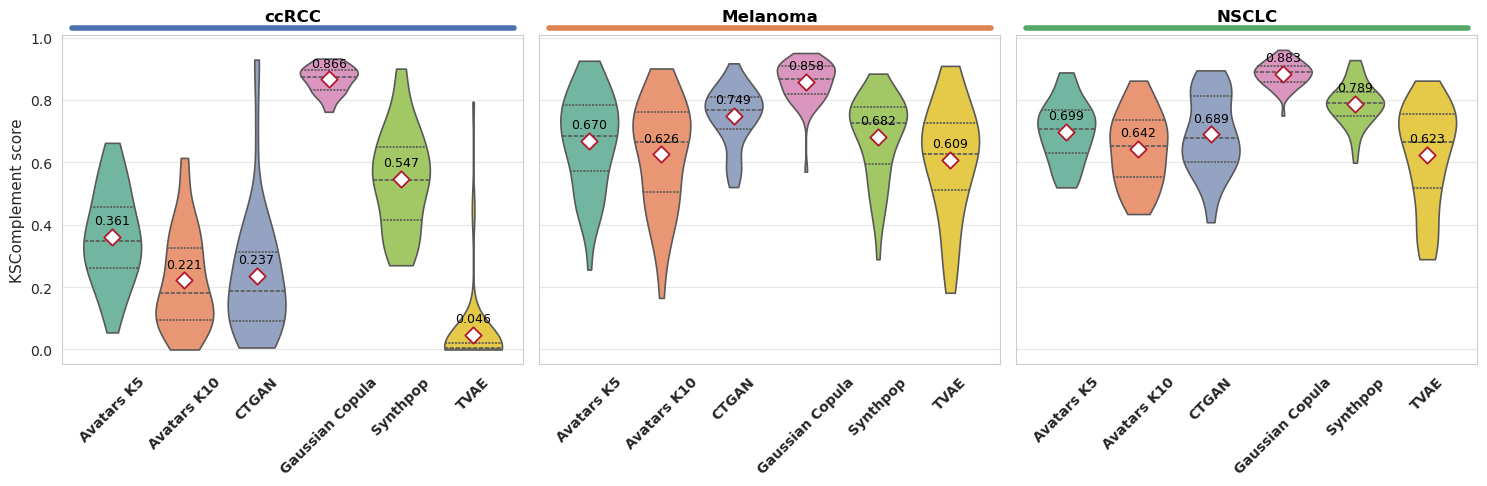

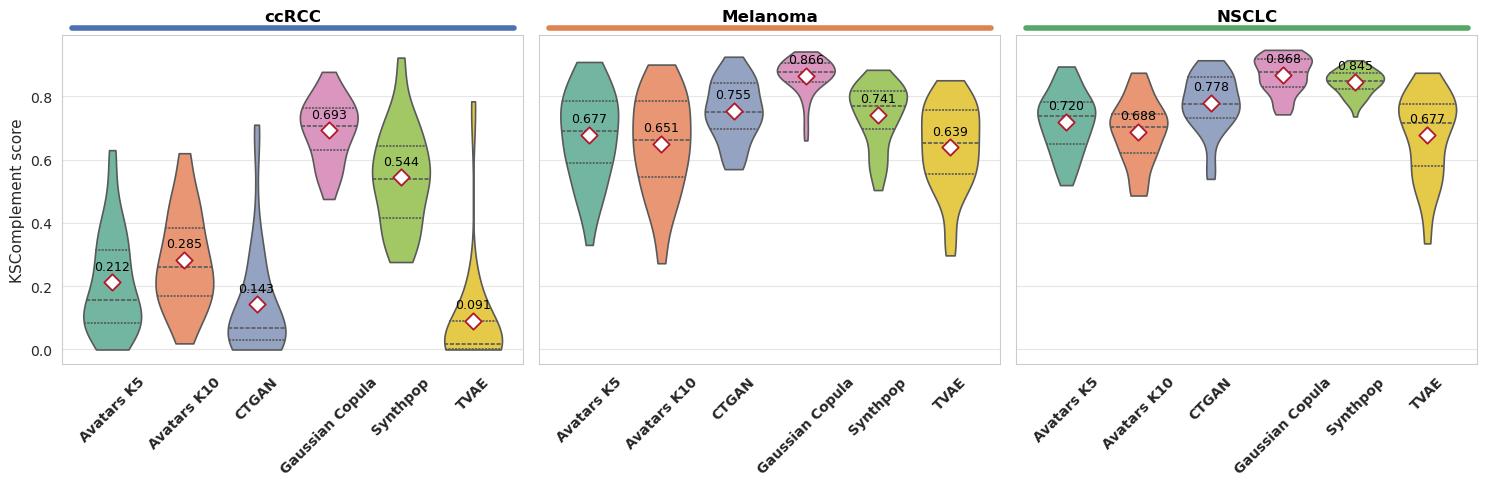

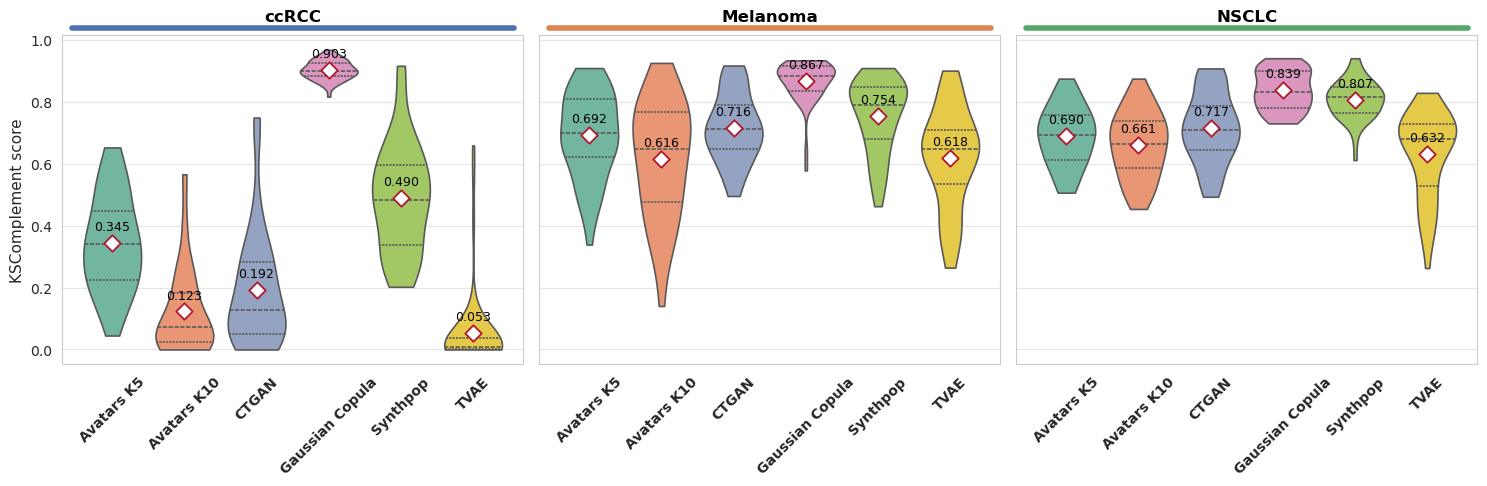

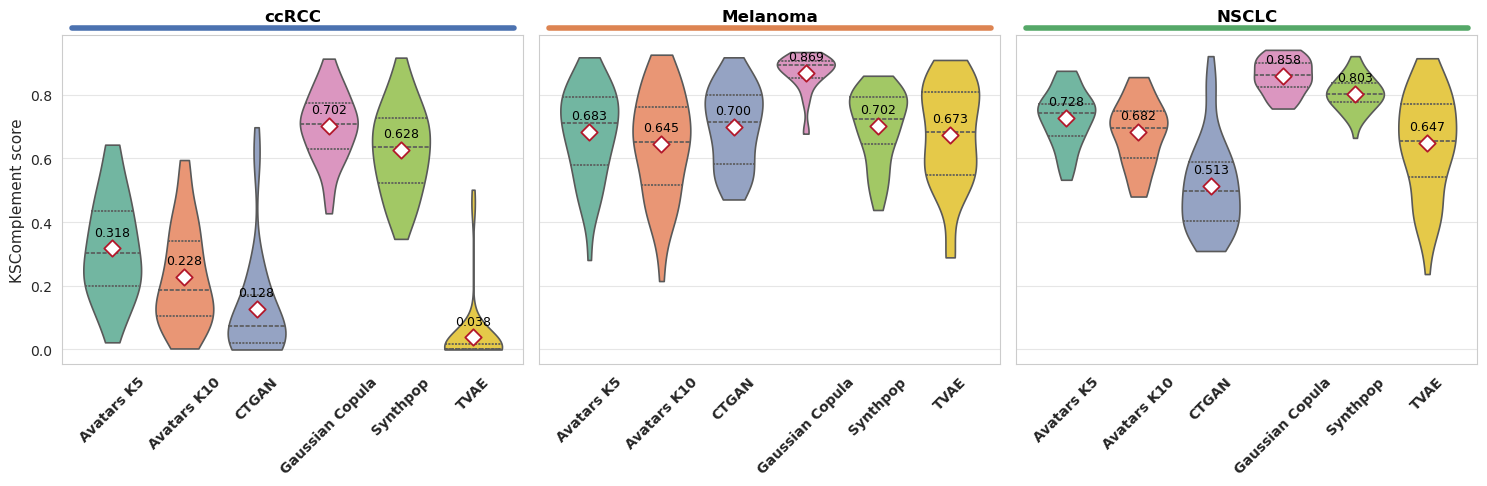

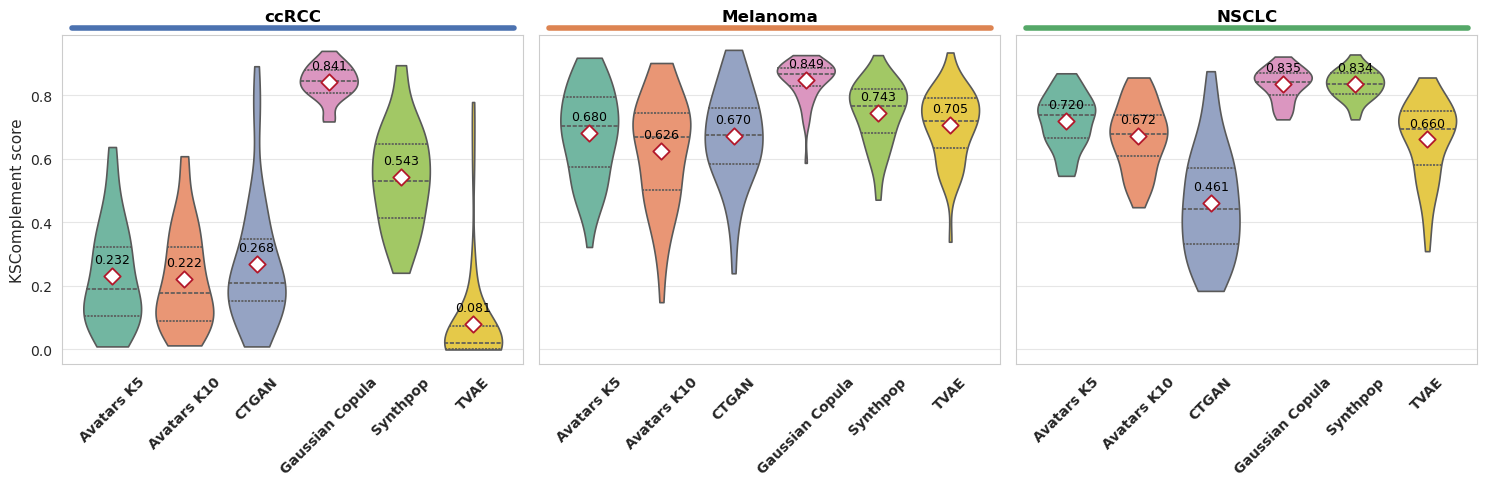

In [6]:
import pandas as pd
import numpy as np
from SynOmics.metrics.fidelity.visualization import plot_violin_grid_by_cancer
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

cancers = ['ccRCC', 'Melanoma', 'NSCLC']

names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']
seeds = [0,1,2,3,42]
for seed in seeds:
    datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}',f'ctgan_{seed}',f'gaussiancopula_{seed}',f'synthpop_{seed}',f'tvae_{seed}']
    KS_Score = {}
    for cancer in cancers:
        score_dict = {}
        for i, dataset in enumerate(datasets):
            uni_score_df = pd.read_csv(f'../{cancer}/NarrowUtility/ssGSEA/KSStatistic/Seed_{seed}/Detail_score_{dataset}.csv')
            score = uni_score_df['Score'].fillna(0).tolist()
            score_dict[names[i]]=score 
        KS_Score[cancer]=score_dict
    
    fig, axes, mean_by_cancer = plot_violin_grid_by_cancer(
        cancer_to_method_scores=KS_Score,
        value_name="KSComplement score", 
        methods_order=names,
        palette=DATASET_COLORS,  
        figsize=(15, 5),          
        fontsize=11,
        annotate_mean=True,      
        show=True,
    )
    # fig.savefig(f"KSScore/KSScore_ssGSEA.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(f"KSScore/Seed_{seed}.pdf", bbox_inches="tight", facecolor="white")